# Data Wrangling — Synthetic Vietnamese Students’ Feedback

Nguồn: [Kaggle — toreleon/synthetic-vietnamese-students-feedback-corpus](https://www.kaggle.com/datasets/toreleon/synthetic-vietnamese-students-feedback-corpus)

1. `student_feedback_data/synthetic_train.csv` (train)  
2. `student_feedback_data/synthetic_val.csv` (validation)  

Dữ liệu **văn bản**: missing → làm sạch câu; chuẩn hoá đơn vị → điểm sentiment; normalize → độ dài câu; binning → ngắn/trung/dài; dummy → `topic`.

Mỗi bước có **1 dòng mẫu**. Dòng `# TODO` em làm tương tự (đổi tên cột / file).

## Download data and explore

Luôn bắt đầu bằng **nhìn dữ liệu**, đừng nhảy vào `fillna`. Hỏi: bao nhiêu dòng? cột nào object? câu rỗng / chỉ khoảng trắng?

| Cột | Kiểu | Ý nghĩa |
|---|---|---|
| `sentence` | object | Câu phản hồi (VN hoặc EN). Không trùng trong từng file. |
| `sentiment` | object | Nhãn cảm xúc: `negative` / `neutral` / `positive` (gần cân bằng). |
| `topic` | object | Chủ đề: `lecturer`, `curriculum`, `facility`, `others`. |

**Ghi chú:** Không có `NaN` sẵn. Một số câu là tiếng Anh (không dấu). Cần tạo biến số (độ dài câu) để normalize / binning.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("toreleon/synthetic-vietnamese-students-feedback-corpus")

print("Path to dataset files:", path)

C:\Users\HOANG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\HOANG\.cache\kagglehub\datasets\toreleon\synthetic-vietnamese-students-feedback-corpus\versions\1


In [2]:
import os
os.listdir(r"C:\Users\HOANG\.cache\kagglehub\datasets\toreleon\synthetic-vietnamese-students-feedback-corpus\versions\1")

['synthetic_train.csv', 'synthetic_val.csv']

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path_train = os.path.join(path, "synthetic_train.csv")
path_val = os.path.join(path, "synthetic_val.csv")

df_train = pd.read_csv(path_train)  # mẫu: đọc train

# TODO: đọc path_val vào df_val (giống dòng trên)
df_val = pd.read_csv(path_val)

print("Train:", df_train.shape)  # mẫu: in số dòng, số cột

# TODO: in shape của df_val
print(df_val.shape)

print(df_train.dtypes)  # mẫu: xem kiểu cột
df_train.head()  # mẫu: 5 dòng đầu
# TODO: xem 5 dòng đầu df_val
print(df_val.head(5))

Train: (8144, 3)
(2036, 3)
sentence     object
sentiment    object
topic        object
dtype: object
                                            sentence sentiment       topic
0                           Chất lượng vật chất kém.  negative    facility
1  Phần mềm học tập quá khó sử dụng, khiến sinh v...  negative    facility
2  Trường tôi thiếu những tiện ích cơ bản như máy...  negative    facility
3  Cần tạo thêm các hoạt động gắn kết giữa sinh v...   neutral  curriculum
4  Họ rất khoan dung và lượng giác trong quan điể...   neutral      others


---
# Bộ 1 — Train

## 1. Xử lý giá trị thiếu (Missing Values)

Câu rỗng / chỉ khoảng trắng → `NaN`. `sentiment` / `topic` (phân loại) → **mode**. `sentence` là nội dung chính → **drop** dòng thiếu rồi `reset_index`.

In [4]:
df = df_train.copy()  # mẫu: làm việc trên bản sao

df["sentence"] = df["sentence"].astype(str).str.strip()  # mẫu: cắt khoảng trắng câu

# TODO: strip tương tự cho sentiment và topic
df['sentiment'] = df['sentiment'].astype(str).str.strip()
df['topic'] = df['topic'].astype(str).str.strip()

# TODO: replace {"nan": np.nan, "": np.nan, "None": np.nan} trên 3 cột (có thể dùng vòng for)
for c in ['sentence', 'sentiment', 'topic']:
    df[c] = df[c].replace({"nan": np.nan, "": np.nan, "None": np.nan})  

print(df.isnull().sum())  # mẫu: đếm missing trước xử lý

df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode(dropna=True)[0])  # mẫu: cột chữ → mode

# TODO: fillna mode cho cột topic (copy mẫu, đổi tên cột)
df['topic'] = df['topic'].fillna(df['topic'].mode(dropna=True)[0])

# TODO: dropna subset=["sentence"] rồi reset_index (câu là nội dung chính — không điền mode)
df = df.dropna(subset=["sentence"]).reset_index(drop=True)

# TODO: in lại isnull().sum() và len(df)
print(df.isnull().sum())
print(len(df))

sentence     0
sentiment    0
topic        0
dtype: int64
sentence     0
sentiment    0
topic        0
dtype: int64
8144


## 2. Sửa định dạng dữ liệu (Correct Data Format)

Ép `sentiment`, `topic` về kiểu `category`. Thêm độ dài câu (`n_chars`, `n_words`) dạng số.

In [5]:
print(df.dtypes)  # mẫu: kiểu trước khi ép
print()

df["sentiment"] = df["sentiment"].astype("category")  # mẫu: chữ → category

# TODO: ép topic về category (giống dòng trên)
df['topic'] = df['topic'].astype('category')

df["n_chars"] = df["sentence"].str.len().astype(int)  # mẫu: số ký tự
# TODO: n_words = sentence.str.split().str.len() rồi astype(int)
df['n_words'] = df['sentence'].str.split().str.len().astype(int)

df[["sentence", "n_chars"]].head()  # mẫu
# TODO: head thêm cột n_words; in lại dtypes
print(df['n_words'].head())
print(df.dtypes)

sentence     object
sentiment    object
topic        object
dtype: object

0    19
1     8
2    14
3    15
4    34
Name: n_words, dtype: int64
sentence       object
sentiment    category
topic        category
n_chars         int64
n_words         int64
dtype: object


## 3. Chuẩn hoá dữ liệu (Data Standardization)

Đưa nhãn cảm xúc về **cùng thang số**: `negative → -1`, `neutral → 0`, `positive → 1`.

In [6]:
sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}  # mẫu: từ điển nhãn → số

# TODO: cột sentiment_score = df["sentiment"].map(sentiment_map).astype(int)
df['sentiment_score'] = df['sentiment'].map(sentiment_map).astype(int)

df[["sentiment"]].drop_duplicates()  # mẫu: xem các nhãn
# TODO: head / drop_duplicates hai cột sentiment và sentiment_score
print(df[['sentiment', 'sentiment_score']].drop_duplicates().head())

  sentiment  sentiment_score
0  negative               -1
1   neutral                0
3  positive                1


## 4. Chuẩn hoá phạm vi giá trị (Data Normalization)

`n_chars` lớn hơn `n_words` → `x / x.max()` về 0–1.

In [7]:
df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max()  # mẫu: chia max → 0–1

# TODO: n_words_normalized = n_words / n_words.max()
df['n_words_normalized'] = df['n_words'] / df['n_words'].max()

df[["n_chars", "n_chars_normalized"]].head()  # mẫu
# TODO: head thêm n_words và n_words_normalized
print(df[['n_words', 'n_words_normalized']].head())

   n_words  n_words_normalized
0       19            0.441860
1        8            0.186047
2       14            0.325581
3       15            0.348837
4       34            0.790698


## 5. Phân nhóm (Binning)

Chia độ dài câu (số từ) thành Short / Medium / Long bằng `pd.cut()`.

length_binned
Short     5070
Medium    2978
Long        96
Name: count, dtype: int64


,n_words,length_binned
0,19,Medium
1,8,Short
2,14,Short
3,15,Short
4,34,Long


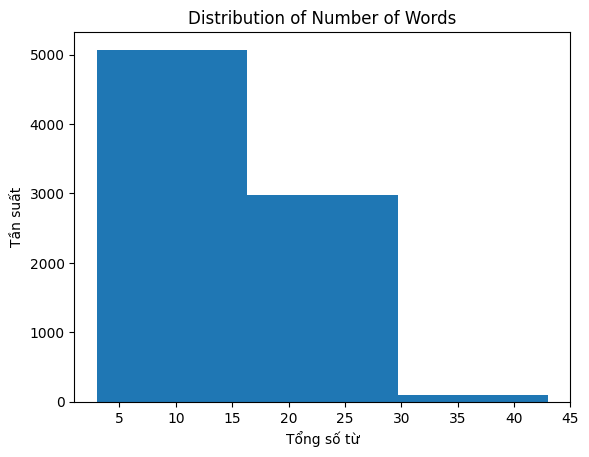

In [8]:
bins = np.linspace(df["n_words"].min(), df["n_words"].max(), 4)  # mẫu: 3 khoảng đều

df["length_binned"] = pd.cut(
    df["n_words"], bins=bins, labels=["Short", "Medium", "Long"], include_lowest=True
)  # mẫu: gán nhãn

print(df["length_binned"].value_counts())  # mẫu: đếm mỗi nhóm

# TODO: plt.hist(df["n_words"], bins=3) rồi xlabel / ylabel / title / show
plt.hist(df["n_words"], bins=3)
plt.xlabel("Tổng số từ")
plt.ylabel("Tần suất")
plt.title("Distribution of Number of Words")

df[["n_words", "length_binned"]].head()

## 6. Biến chỉ thị / Biến giả (Dummy Variable)

`topic` (chữ) → mỗi chủ đề một cột 0/1. Giữ `sentiment` làm nhãn dự đoán.

In [9]:
dummy_topic = pd.get_dummies(df["topic"], prefix="topic", dtype=int)  # mẫu: cột 0/1

# TODO: gộp dummy vào df — pd.concat([df, dummy_topic], axis=1)
df = pd.concat([df, dummy_topic], axis=1)

# TODO: xoá cột gốc topic — df.drop(columns=["topic"])  (giữ sentiment)
df = df.drop(columns=["topic"])
df.head()  # mẫu

,sentence,sentiment,n_chars,n_words,sentiment_score,n_chars_normalized,n_words_normalized,length_binned,topic_curriculum,topic_facility,topic_lecturer,topic_others
0,Đội ngũ bảo trì quá thưa thớt dẫn đến không đả...,negative,86,19,-1,0.452632,0.441860,Medium,0,1,0,0
1,The university's musical and artistic faciliti...,neutral,63,8,0,0.331579,0.186047,Short,0,1,0,0
2,Phương pháp giảng dạy phù hợp với các đối tượn...,neutral,68,14,0,0.357895,0.325581,Short,1,0,0,0
3,Chương trình học giúp tôi trở thành một chuyên...,positive,75,15,1,0.394737,0.348837,Short,1,0,0,0
4,Tôi nghĩ rằng chương trình đào tạo có thể có t...,neutral,142,34,0,0.747368,0.790698,Long,1,0,0,0


## Check and save

Trước khi `to_csv`:

* `isnull().sum()` còn 0 (hoặc đúng chỗ cố ý để thiếu)
* `n_chars`, `n_words` là số
* có cột mới: `sentiment_score`, `*_normalized`, `length_binned`, `topic_*`

`index=False` để file không thêm cột index 0,1,2,…


In [10]:
df.to_csv("student_feedback_train_clean.csv", index=False)  # mẫu: lưu train
print(df.shape)

# TODO: (tuỳ chọn) gán df_train_clean = df
df_train_clean = df

(8144, 12)


---
---
# Bộ 2 — Validation

Làm **giống bộ train**, đổi `df_train` → `df_val`. Copy mẫu ở trên, sửa tên biến / title. Kết thúc bằng **Check and save** (`to_csv`, `index=False`).


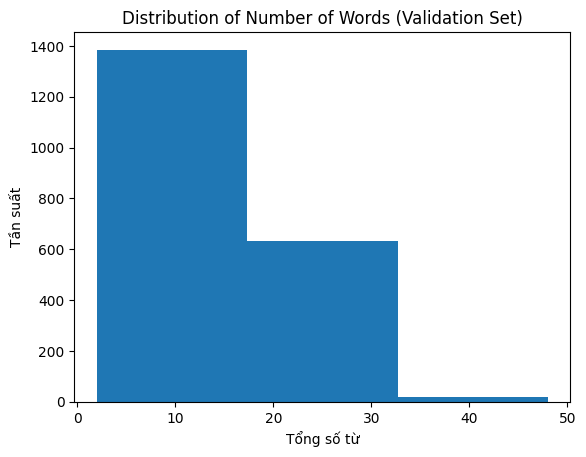

(2036, 13)


In [11]:
df = df_val.copy()  # mẫu: bắt đầu từ validation

df["sentence"] = df["sentence"].astype(str).str.strip()  # mẫu bước 1
# TODO: strip + replace nan/""/"None" cho sentiment, topic; fillna mode; dropna sentence
df['sentiment'] = df['sentiment'].astype(str).str.strip()
df['topic'] = df['topic'].astype(str).str.strip()
for c in ['sentiment', 'topic']:
    df[c] = df[c].replace({"nan": np.nan, "": np.nan, "None": np.nan})
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode(dropna=True)[0])
df['topic'] = df['topic'].fillna(df['topic'].mode(dropna=True)[0])
df = df.dropna(subset=['sentence']).reset_index(drop=True)

df["sentiment"] = df["sentiment"].astype("category")  # mẫu bước 2
# TODO: ép topic; tạo n_chars (đã có mẫu train) và n_words
df['topic'] = df['topic'].astype('category')
df['n_chars'] = df['sentence'].str.len().astype(int)
df['n_words'] = df['sentence'].str.split().str.len().astype(int)

sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}  # mẫu bước 3
# TODO: sentiment_score = map rồi astype(int)
df['sentiment_score'] = df['sentiment'].map(sentiment_map).astype(int)

df["n_chars_normalized"] = df["n_chars"] / df["n_chars"].max()  # mẫu bước 4
# TODO: n_words_normalized
df['n_words_normalized'] = df['n_words'] / df['n_words'].max()

# TODO: bước 5 — linspace + pd.cut + value_counts + hist (title Val)
bins = np.linspace(df['n_words'].min(), df['n_words'].max(), 4)
df['length_binned'] = pd.cut(df['n_words'], bins=bins, labels=['Short', 'Medium', 'Long'], include_lowest=True)
plt.hist(df['n_words'], bins=3)
plt.xlabel("Tổng số từ")
plt.ylabel("Tần suất")
plt.title("Distribution of Number of Words (Validation Set)")
plt.show()

dummy_topic = pd.get_dummies(df["topic"], prefix="topic", dtype=int)  # mẫu bước 6
# TODO: concat + drop topic
df = pd.concat([df, dummy_topic], axis=1)

# TODO: to_csv student_feedback_val_clean.csv; print shape; df.head()
df.to_csv("student_feedback_val_clean.csv", index=False)
print(df.shape)
df_val_clean = df